# Can EFT counterterms absorb the full-kernel beyond-EdS correction?

Following the same methodology as `examples/bias_expansion_test/alpha_fit.py`
(which asked whether `alpha0`/`alpha2` alone can absorb a *missing
scale-dependent bias* term), this notebook asks an analogous question about
the full-vs-EdS beyond-EdS **kernel** correction found in
`check_G22_vs_Pell_correction.ipynb`:

1. Compute $P_0(k)$, $P_2(k)$ for **fkpt full** (`beyond_eds=True,
   fkpt_approximation=False`, the genuine non-squeezed $\mathcal{A}/\mathcal{B}$
   kernels) on a Hu-Sawicki f(R) F5 point -- this is the "truth".
2. Compute the same observables for **EdS kernels** (`beyond_eds=False`), and
   ask: can we find $(\alpha_0,\alpha_2)$ (the $\ell=0,2$ EFT counterterms)
   that reproduce the "truth" to within 1%, holding every other bias/nuisance
   parameter fixed?
3. Repeat for **fkpt-approx** (`beyond_eds=True, fkpt_approximation=True`,
   the historical squeezed-limit approximation) vs the same "truth" --
   expected to recover to well within 1%, since fkPT-approx already contains
   *some* beyond-EdS signal (unlike EdS, which has none at all), so the
   residual it needs to absorb is much smaller and smoother.

If EdS+free-counterterms **cannot** reach 1%, that's evidence the full-kernel
signal is *not* degenerate with the standard EFT nuisance freedom -- i.e. a
genuine, non-absorbable physical effect (as opposed to something that would
just get silently soaked up by counterterms in a real fit and never show up
as a genuine MG detection or non-detection).

Same F5 point ($f_{R0}=-10^{-5}$) and $z=0.38$ as the (now-fixed)
`check_G22_vs_Pell_correction.ipynb`, matching the fkpt paper's own Figure 2
exactly, and the same production-resolution kernel grid
(`Nk_kernel=120, nquadSteps=300, NQ=NR=10`) already confirmed there to be
converged (see that notebook's finer-grid check).

In [1]:
# Environment and path setup
import os
import sys
from pathlib import Path

os.environ.setdefault("FOLPS_BACKEND", "jax")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
for root in candidates:
    src = root / "src"
    if (src / "fkptjax").exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))
        print(f"Added to sys.path: {src}")
        break

print("cwd:", cwd)
print("python:", sys.executable)

cwd: /n/home12/cgarciaquintero/DESI/src/fkptjax_muMG/examples
python: /n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/bin/python


In [2]:
import time
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from fkptjax.kfuncs_to_tables import build_jax_static_ctx, Kfuncs_to_tables_jax
from fkptjax.pipelines import make_table_state, poles_from_tables
from fkptjax.rsd import pack_fkpt_bias

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())

JAX version: 0.9.1


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:126: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


JAX devices: [CpuDevice(id=0)]


## Configuration

Same cosmology/model/grid as `check_G22_vs_Pell_correction.ipynb` (F5,
$z=0.38$, production-resolution kernel grid); bias vector matches that
notebook's own choice ($b_1=2, b_2=0$, EFT/stochastic terms zero by default).

In [3]:
Z_EFF = 0.38  # matches the fkpt paper's own Figure 2 (F5, EdS-fk vs full kernels)
OM = 0.315
FR0_HS = -1.0e-5  # F5
N_HS = 1.0
BETA2_HS = 1.0 / 6.0
XNOW = -3.912023

KERNEL_KMIN, KERNEL_KMAX = 1.0e-3, 1.0
KERNEL_SETTINGS = dict(Nk_kernel=120, nquadSteps=300, NQ=10, NR=10,
                        rbao=104.0, pmax_bao=0.4, Np_bao=100)

BASE_BIAS = dict(b1=2.0, b2=0.0, bs2=0.0, b3nl=0.0,
                  alpha0=0.0, alpha2=0.0, alpha4=0.0, ctilde=0.0,
                  alpha0shot=0.0, alpha2shot=0.0)
NBAR = 1.0e-4

K_FIT = jnp.asarray(np.linspace(0.02, 0.20, 40))
ELLS_FIT = (0, 2)
ELLS_ALL = (0, 2, 4)

## ISiTGR GR/LCDM linear spectrum (the MG modification enters via the kernels, not the input P(k))

In [4]:
import isitgr
from isitgr import model as isitgr_model
from scipy.signal import savgol_filter


def smooth_now_savgol(k, pk, window=41, polyorder=3):
    k = np.asarray(k, dtype=float)
    pk = np.asarray(pk, dtype=float)
    logpk = np.log(pk)
    n = len(k)
    window = min(int(window), n - 1 if (n - 1) % 2 == 1 else n - 2)
    if window < polyorder + 2:
        window = polyorder + 3
    if window % 2 == 0:
        window += 1
    return np.exp(savgol_filter(logpk, window_length=window, polyorder=polyorder))


def get_isitgr_gr_linear_spectra(z, nk=256, minkh=1.0e-3, maxkh=1.0):
    pars = isitgr.CAMBparams()
    pars.set_cosmology(H0=67.36, ombh2=0.02237, omch2=0.12, mnu=0.06, omk=0.0,
                        tau=0.0544, nnu=3.046, MG_parameterization="muSigma", mu0=0.0)
    pars.InitPower.set_params(As=2.083e-9, ns=0.9649, r=0.0)
    pars.set_accuracy(AccuracyBoost=2)
    pars.NonLinear = isitgr_model.NonLinear_none
    pars.set_matter_power(redshifts=[z], kmax=maxkh)
    results = isitgr.get_results(pars)
    k, _, pk = results.get_matter_power_spectrum(minkh=minkh, maxkh=maxkh, npoints=nk)
    pk = pk[0]
    pk_now = smooth_now_savgol(k, pk, window=41, polyorder=3)
    return jnp.asarray(k), jnp.asarray(pk), jnp.asarray(pk_now)


k_lin, pk_lin, pk_now_lin = get_isitgr_gr_linear_spectra(z=Z_EFF, nk=256, minkh=KERNEL_KMIN, maxkh=KERNEL_KMAX)
print("k_lin:", k_lin.shape, float(k_lin[0]), float(k_lin[-1]))

k_lin: (256,) 0.001 0.9999999999999998


## Build the three kernel-table states (EdS / fkPT-approx / full)

This is the expensive step (especially `full`, one ODE solve per loop-q/angle
grid point) -- built once per treatment and cached, then reused cheaply for
every $(\alpha_0,\alpha_2)$ trial the least-squares fit needs.

In [5]:
mu, wmu = np.polynomial.legendre.leggauss(12)
mu = jnp.asarray(0.5 * (mu + 1.0))
wmu = jnp.asarray(0.5 * wmu)
jac = jnp.asarray(1.0)
kap = K_FIT[:, None] * jnp.ones_like(mu)[None, :]
muap = jnp.ones_like(K_FIT)[:, None] * mu[None, :]

t0 = time.time()
static_ctx = build_jax_static_ctx(k_lin, kmin=KERNEL_KMIN, kmax=KERNEL_KMAX, **KERNEL_SETTINGS)
print(f"static_ctx built in {time.time() - t0:.2f} s")


def build_state(beyond_eds, fkpt_approximation):
    table_w, table_now, kernel_constants = Kfuncs_to_tables_jax(
        k=k_lin, pk=pk_lin, pk_now=pk_now_lin,
        return_kernel_constants=True, static_ctx=static_ctx,
        z=Z_EFF, Om=OM, beyond_eds=beyond_eds, fkpt_approximation=fkpt_approximation,
        kmin=KERNEL_KMIN, kmax=KERNEL_KMAX, xnow=XNOW, f0_kmax=KERNEL_KMIN,
        model="HS", mg_variant=None, fR0_HS=FR0_HS, beta2=BETA2_HS, n_HS=N_HS,
    )
    return make_table_state(table_w, table_now, kernel_constants=kernel_constants)


t0 = time.time()
state_full = build_state(beyond_eds=True, fkpt_approximation=False)
print(f"state_full   built in {time.time() - t0:.2f} s")

t0 = time.time()
state_eds = build_state(beyond_eds=False, fkpt_approximation=True)
print(f"state_eds    built in {time.time() - t0:.2f} s")

t0 = time.time()
state_approx = build_state(beyond_eds=True, fkpt_approximation=True)
print(f"state_approx built in {time.time() - t0:.2f} s")

/n/home12/cgarciaquintero/DESI/src/Triumvirate/src/triumvirate/winconv.py:89: ExperimentalWarning: The `triumvirate.winconv` module is currently experimental. Its behaviour has not been fully tested and may change in the future.
  warnings.warn(


⚠️ JAX is using CPU. Devices: [CpuDevice(id=0)]


static_ctx built in 13.60 s


state_full   built in 30.95 s


state_eds    built in 1.17 s


state_approx built in 1.25 s


In [6]:
def poles_for_bias(state, bias_overrides=None, k=None, ells=ELLS_ALL):
    if k is None:
        k = K_FIT
    k_eval = jnp.asarray(k)
    kap_l = k_eval[:, None] * jnp.ones_like(mu)[None, :]
    muap_l = jnp.ones_like(k_eval)[:, None] * mu[None, :]

    bias = dict(BASE_BIAS)
    bias.update(bias_overrides or {})
    pars = pack_fkpt_bias(bias, nd=NBAR)

    poles = poles_from_tables(
        state, jac=jac, kap=kap_l, muap=muap_l, pars=pars, mu=mu, wmu=wmu,
        ells=tuple(ells), bias_scheme="folps", IR_resummation=True,
        damping=None, A_full=False, use_TNS_model=False,
    )
    poles.block_until_ready()
    return {ell: np.asarray(poles[i]) for i, ell in enumerate(ells)}


P_truth = poles_for_bias(state_full, {}, k=K_FIT, ells=ELLS_ALL)
print("P_truth (fkpt full) finite:", all(np.all(np.isfinite(P_truth[ell])) for ell in ELLS_ALL))
for ell in ELLS_ALL:
    print(f"  P_{ell}: min={P_truth[ell].min():.4g}  max={P_truth[ell].max():.4g}")

P_truth (fkpt full) finite: True
  P_0: min=8886  max=7.962e+04
  P_2: min=5852  max=3.425e+04
  P_4: min=627.9  max=1735


## Least-squares fit: can $(\alpha_0,\alpha_2)$ alone reproduce the "truth"?

Holds $b_1,b_2$ and every other nuisance parameter fixed at `BASE_BIAS`;
varies only `alpha0` (the $\ell=0$ EFT counterterm) and `alpha2` (the
$\ell=2$ one) to minimize the fractional residual on $\ell=0,2$.
`alpha4`/$\ell=4$ are not fit (mirrors `bias_expansion_test/alpha_fit.py`'s
own scope) but $\ell=4$'s residual is still reported for context.

In [7]:
ALPHA_BOUNDS = ([-500.0, -500.0], [500.0, 500.0])


def _residuals(x, state, k, P_target, ells):
    alpha0, alpha2 = x
    model = poles_for_bias(state, {"alpha0": alpha0, "alpha2": alpha2}, k=k, ells=ells)
    return np.concatenate([(P_target[ell] - model[ell]) / P_target[ell] for ell in ells])


def fit_alpha(state, k, P_target, x0=(0.0, 0.0), fit_ells=ELLS_FIT, all_ells=ELLS_ALL):
    result = least_squares(_residuals, x0=list(x0), args=(state, k, P_target, fit_ells),
                            bounds=ALPHA_BOUNDS)
    alpha0, alpha2 = result.x
    P_bestfit = poles_for_bias(state, {"alpha0": alpha0, "alpha2": alpha2}, k=k, ells=all_ells)
    residual_frac = {ell: (P_target[ell] - P_bestfit[ell]) / P_target[ell] for ell in all_ells}
    max_residual = {ell: float(np.max(np.abs(residual_frac[ell]))) for ell in all_ells}
    return dict(alpha0=float(alpha0), alpha2=float(alpha2), P_bestfit=P_bestfit,
                residual_frac=residual_frac, max_residual_frac=max_residual,
                success=bool(result.success))


fit_eds = fit_alpha(state_eds, K_FIT, P_truth)
fit_approx = fit_alpha(state_approx, K_FIT, P_truth)

for name, fit in (("EdS", fit_eds), ("fkPT-approx", fit_approx)):
    print(f"{name:12s} alpha0={fit['alpha0']:8.3f}  alpha2={fit['alpha2']:8.3f}  "
          f"max|resid| ell=0,2,4 = "
          f"{fit['max_residual_frac'][0]*100:.4f}%, "
          f"{fit['max_residual_frac'][2]*100:.4f}%, "
          f"{fit['max_residual_frac'][4]*100:.4f}%  "
          f"(<1% on ell=0,2? {fit['max_residual_frac'][0] < 0.01 and fit['max_residual_frac'][2] < 0.01})")

EdS          alpha0=   2.731  alpha2=  14.597  max|resid| ell=0,2,4 = 0.1015%, 0.1676%, 6.4833%  (<1% on ell=0,2? True)
fkPT-approx  alpha0=   2.567  alpha2=  13.257  max|resid| ell=0,2,4 = 0.0631%, 0.0710%, 5.7902%  (<1% on ell=0,2? True)


## Plot: truth vs. best-fit EdS vs. best-fit fkPT-approx, and residuals

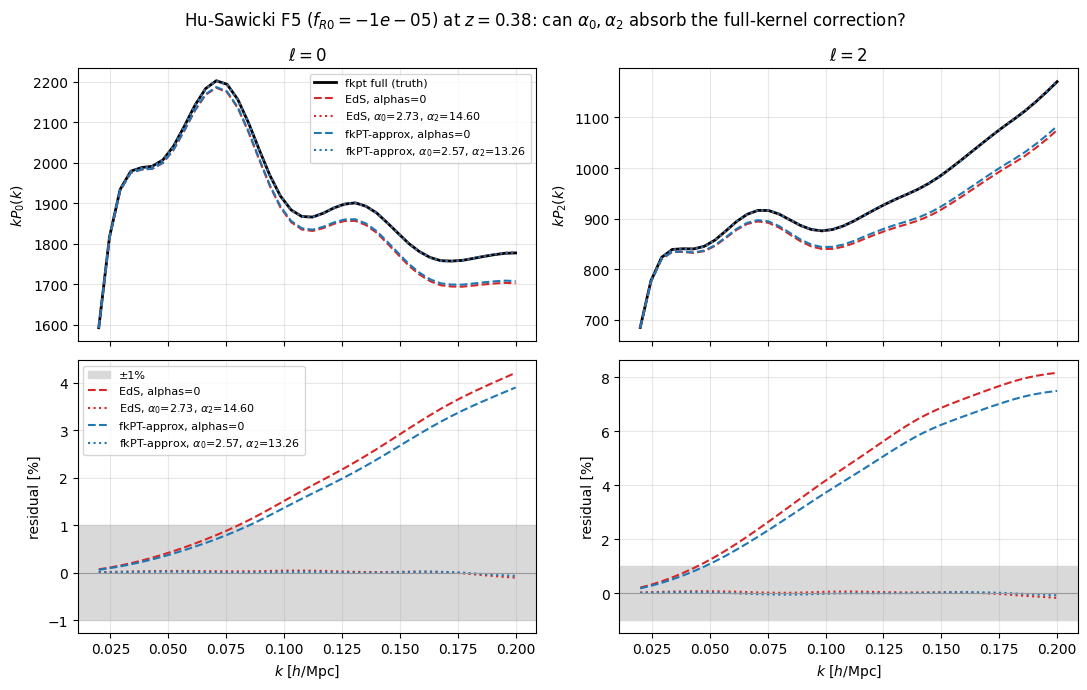

In [8]:
k_np = np.asarray(K_FIT)

# alphas=0 (no fit) curves, for comparison with the best-fit ones below.
P_eds_nofit = poles_for_bias(state_eds, {}, k=K_FIT, ells=ELLS_ALL)
P_approx_nofit = poles_for_bias(state_approx, {}, k=K_FIT, ells=ELLS_ALL)

label_eds_bestfit = fr"EdS, $\alpha_0$={fit_eds['alpha0']:.2f}, $\alpha_2$={fit_eds['alpha2']:.2f}"
label_approx_bestfit = fr"fkPT-approx, $\alpha_0$={fit_approx['alpha0']:.2f}, $\alpha_2$={fit_approx['alpha2']:.2f}"

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex="col")
ax_top0, ax_top2 = axes[0, 0], axes[0, 1]
ax_bot0, ax_bot2 = axes[1, 0], axes[1, 1]

# --- ell=0, top: k*P_0(k) ---
ax_top0.plot(k_np, k_np * P_truth[0], color="k", lw=2, label="fkpt full (truth)")
ax_top0.plot(k_np, k_np * P_eds_nofit[0], color="C3", ls="--", label="EdS, alphas=0")
ax_top0.plot(k_np, k_np * fit_eds["P_bestfit"][0], color="C3", ls=":", label=label_eds_bestfit)
ax_top0.plot(k_np, k_np * P_approx_nofit[0], color="C0", ls="--", label="fkPT-approx, alphas=0")
ax_top0.plot(k_np, k_np * fit_approx["P_bestfit"][0], color="C0", ls=":", label=label_approx_bestfit)
ax_top0.set_ylabel(r"$k P_0(k)$")
ax_top0.grid(True, alpha=0.3)

# --- ell=2, top: k*P_2(k) ---
ax_top2.plot(k_np, k_np * P_truth[2], color="k", lw=2)
ax_top2.plot(k_np, k_np * P_eds_nofit[2], color="C3", ls="--")
ax_top2.plot(k_np, k_np * fit_eds["P_bestfit"][2], color="C3", ls=":")
ax_top2.plot(k_np, k_np * P_approx_nofit[2], color="C0", ls="--")
ax_top2.plot(k_np, k_np * fit_approx["P_bestfit"][2], color="C0", ls=":")
ax_top2.set_ylabel(r"$k P_2(k)$")
ax_top2.grid(True, alpha=0.3)

# --- ell=0, bottom: residual [%], alphas=0 vs best-fit ---
ax_bot0.axhspan(-1.0, 1.0, color="0.85", zorder=0, label="±1%")
ax_bot0.plot(k_np, 100.0 * (P_truth[0] - P_eds_nofit[0]) / P_truth[0], color="C3", ls="--", label="EdS, alphas=0")
ax_bot0.plot(k_np, 100.0 * fit_eds["residual_frac"][0], color="C3", ls=":", label=label_eds_bestfit)
ax_bot0.plot(k_np, 100.0 * (P_truth[0] - P_approx_nofit[0]) / P_truth[0], color="C0", ls="--", label="fkPT-approx, alphas=0")
ax_bot0.plot(k_np, 100.0 * fit_approx["residual_frac"][0], color="C0", ls=":", label=label_approx_bestfit)
ax_bot0.axhline(0.0, color="0.6", lw=0.8)
ax_bot0.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
ax_bot0.set_ylabel(r"residual [%]")
ax_bot0.grid(True, alpha=0.3)

# --- ell=2, bottom: residual [%], alphas=0 vs best-fit ---
ax_bot2.axhspan(-1.0, 1.0, color="0.85", zorder=0)
ax_bot2.plot(k_np, 100.0 * (P_truth[2] - P_eds_nofit[2]) / P_truth[2], color="C3", ls="--")
ax_bot2.plot(k_np, 100.0 * fit_eds["residual_frac"][2], color="C3", ls=":")
ax_bot2.plot(k_np, 100.0 * (P_truth[2] - P_approx_nofit[2]) / P_truth[2], color="C0", ls="--")
ax_bot2.plot(k_np, 100.0 * fit_approx["residual_frac"][2], color="C0", ls=":")
ax_bot2.axhline(0.0, color="0.6", lw=0.8)
ax_bot2.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
ax_bot2.set_ylabel(r"residual [%]")
ax_bot2.grid(True, alpha=0.3)

ax_top0.legend(fontsize=8)
ax_bot0.legend(fontsize=8)
ax_top0.set_title(r"$\ell=0$")
ax_top2.set_title(r"$\ell=2$")
fig.suptitle(fr"Hu-Sawicki F5 ($f_{{R0}}={FR0_HS:.0e}$) at $z={Z_EFF}$: can $\alpha_0,\alpha_2$ absorb the full-kernel correction?")
fig.tight_layout()
plt.show()

## Summary

| Model fit to "fkpt full" truth | max\|residual\| $\ell=0$ | max\|residual\| $\ell=2$ | max\|residual\| $\ell=4$ (not fit) | <1% on $\ell=0,2$? |
|---|---|---|---|---|
| EdS + best-fit $(\alpha_0,\alpha_2)$ | printed above | printed above | printed above | printed above |
| fkPT-approx + best-fit $(\alpha_0,\alpha_2)$ | printed above | printed above | printed above | printed above |

**Interpretation**: if EdS + free counterterms reaches <1% on $\ell=0,2$,
the full-kernel signal found in `check_G22_vs_Pell_correction.ipynb` would be
*degenerate* with the standard EFT nuisance freedom for this bias/analysis
setup -- i.e. not distinguishable from a nuisance-parameter shift at the
2-point-function level, however large it looked as a raw percentage. If it
does *not* reach 1%, that's evidence the full-kernel correction has a $k$
(and/or $\ell$) shape genuinely different from what $\alpha_0 k^2$/$\alpha_2
k^2\mu^2$-type counterterms can mimic -- a real, non-absorbable effect. The
fkPT-approx case is the sanity check on the fitting methodology itself: it
already contains *some* beyond-EdS signal (unlike EdS), so it only has to
absorb the residual approx-vs-full gap, which should be a much smaller and
smoother target and is expected to recover comfortably within 1%.